# Análise Exploratória de Dados - Credit Card Fraud Detection
**Autor**: Gustavo Duarte Amorim

**AI Co-authored**: Este notebook contém código gerado por IA (Gemini 3.0 Flash) revisado por humanos.

Este colab conduz uma análise exploratória do dataset [Credit Card Fraud Detection, (Kaggle - 2018)](https://www.kaggle.com/datasetsa/mlg-ulb/creditcardfraud), e faz parte do processo de AGEMC realizado por estudantes da Universidade Federal de Goiás para a disciplina de Pensamento Analítico de Dados.

O objetivo dessa análise é responder a pergunta: "É possível detectar transações fraudulentas em cartões de crédito com alta precisão, mesmo diante de um conjunto de dados extremamente desbalanceado?"

Para isso, vamos explorar os dados, entender como o dataset está estruturado e realizar uma preparação inicial dos dados para modelá-los posteriormente.


## 0. Importando o dataset via Kaggle

In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


## 1. Inspeção Inicial e Limpeza de Dados

Nesta etapa, realizaremos uma auditoria inicial no conjunto de dados para garantir a qualidade da análise.

### 1.1 Integridade e Tipos de Dados

Vamos analisar a integridade dos dados (verificar se existem valores nulos ou duplicatas) e tratarmos os dados para trabalharmos com eles.

In [17]:
import pandas as pd
import os

# 1.1. Integridade e Carregamento
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)
df = pd.read_csv(full_path)

print("### 1.1. Integridade e Tipos de Dados")
print(f"\nFormato inicial: {df.shape}")
print("\n--- Valores Nulos ---")
print(df.isnull().sum().sum())

duplicados = df.duplicated().sum()
print(f"\n--- Duplicatas: {duplicados} ---")
df = df.drop_duplicates() if duplicados > 0 else df
print(f"Formato após limpeza: {df.shape}")

### 1.1. Integridade e Tipos de Dados

Formato inicial: (284807, 31)

--- Valores Nulos ---
0

--- Duplicatas: 1081 ---
Formato após limpeza: (283726, 31)


### 1.2 Calculando correlação apenas com a variável alvo para simplificar

Nessa etapa, calculamos a correlação entre as features do dataset e a variável alvo para identificar quais contribuem mais para identificar ou não uma fraude

### 1.2. Correlação das Variáveis


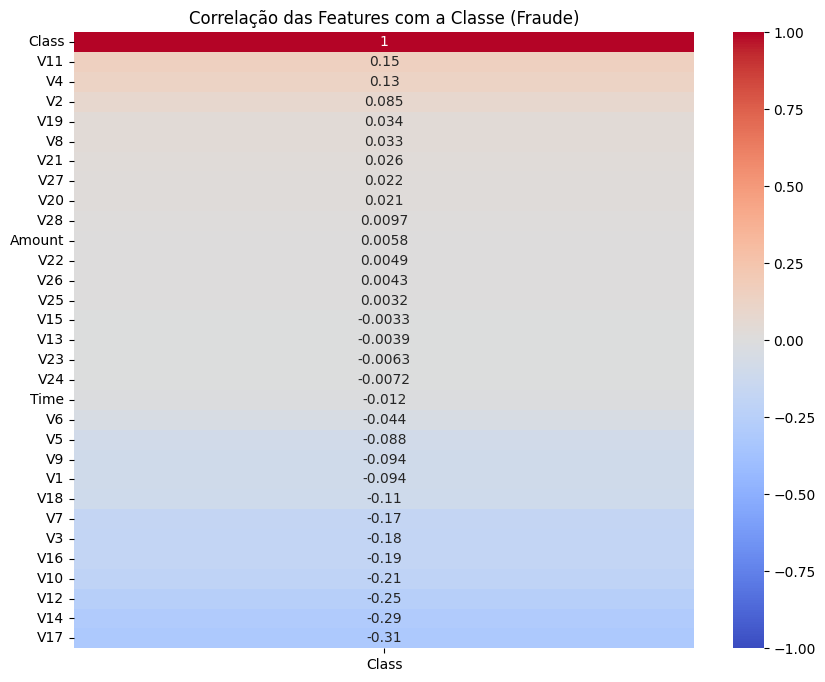

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

print("### 1.2. Correlação das Variáveis")
plt.figure(figsize=(10, 8))

corr = df.corr()
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação das Features com a Classe (Fraude)')
plt.show()

### 1.3 Distribuição das Classes

Visualizando como o dataset está distribuído (entre transações classificadas como fraude ou transação legítima)

### 1.3. Distribuição das Classes


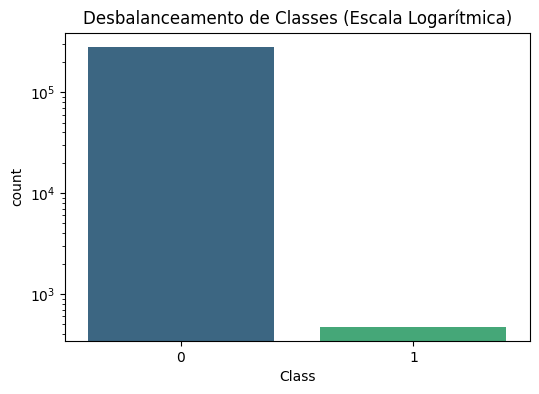

Proporção das classes (0: Legítima, 1: Fraude):
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


In [19]:
print("### 1.3. Distribuição das Classes")
plt.figure(figsize=(6, 4))
# Usando hue para evitar o aviso de depreciação do Seaborn
sns.countplot(x='Class', data=df, hue='Class', palette='viridis', legend=False)
plt.title('Desbalanceamento de Classes (Escala Logarítmica)')
plt.yscale('log')
plt.show()

print("Proporção das classes (0: Legítima, 1: Fraude):")
print(df['Class'].value_counts(normalize=True))

**Análise**: Nesse gráfico é possível visualizar que o dataset está extremamente desbalanceado, possuindo muito mais transações legítimas do que fraudulentas. O insight retirado daqui é que precisaremos trabalhar em cima desse desbalanceamento para garantir que um modelo possa predizer corretamente quais são as transações fraudulentas.

## 2. Análise da Variável 'Time'

Vamos investigar como o tempo se comporta e se ele ajuda a distinguir fraudes de transações legítimas.

Tipo da coluna Time: float64


,Time
count,283726.000000
mean,94811.077600
std,47481.047891
min,0.000000
25%,54204.750000
50%,84692.500000
75%,139298.000000
max,172792.000000



Correlação entre Time e Class: -0.0124


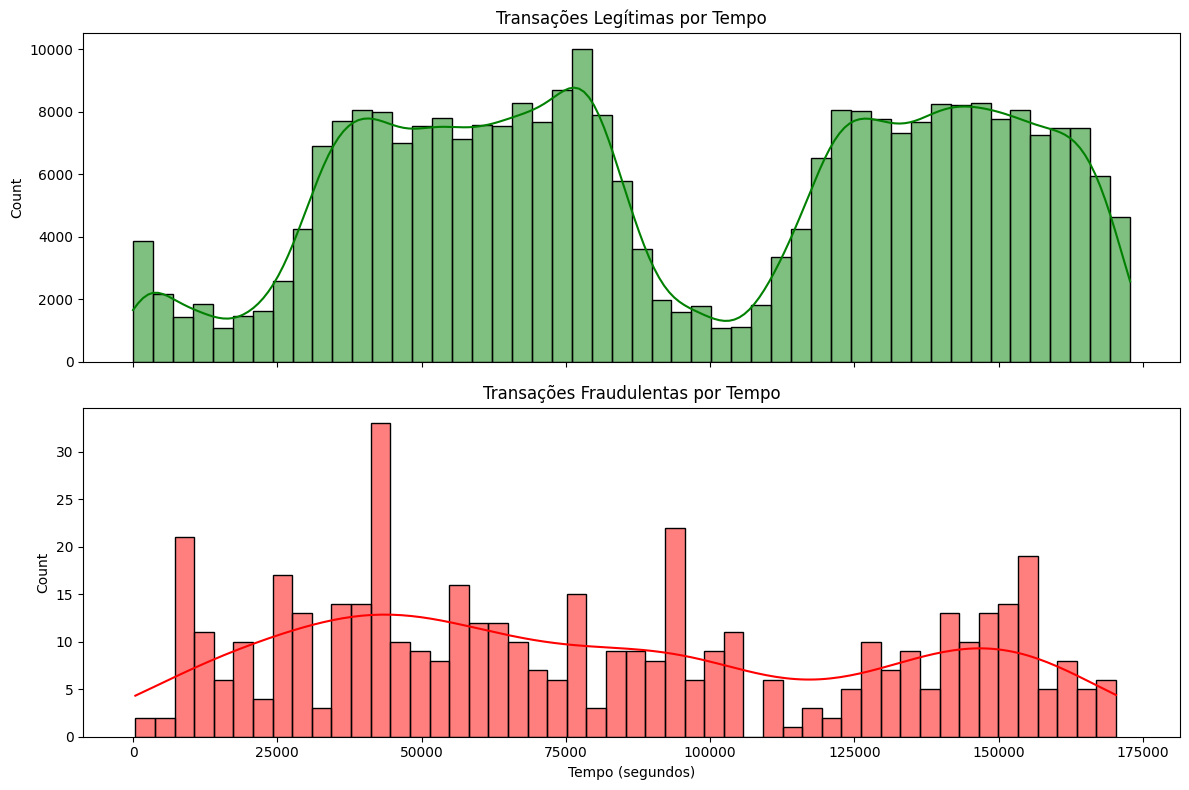

In [20]:
import numpy as np

# 1. Tipo e Estatísticas
print(f"Tipo da coluna Time: {df['Time'].dtype}")
display(df['Time'].describe())

# 2. Correlação específica
corr_time = df[['Time', 'Class']].corr().iloc[0,1]
print(f"\nCorrelação entre Time e Class: {corr_time:.4f}")

# 3. Visualização da Distribuição Temporal
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.histplot(df[df['Class'] == 0]['Time'], bins=50, ax=ax1, color='g', kde=True)
ax1.set_title('Transações Legítimas por Tempo')

sns.histplot(df[df['Class'] == 1]['Time'], bins=50, ax=ax2, color='r', kde=True)
ax2.set_title('Transações Fraudulentas por Tempo')

plt.xlabel('Tempo (segundos)')
plt.tight_layout()
plt.show()

### **Análise Detalhada**: Variável 'Time'

Ao observar os histogramas de distribuição temporal:
- **Transações Legítimas**: Apresentam uma estrutura cíclica clara (provavelmente dia/noite), com vales que representam períodos de sono.
- **Transações Fraudulentas**: Estão distribuídas de forma muito mais uniforme. Não há uma queda tão acentuada durante a 'noite' do dataset, o que indica que a fraude não descansa.
- **Conclusão**: A feature `Time` em sua forma bruta é ruidosa, mas revela que o desvio do padrão de comportamento humano normal (comprar em horários comerciais) é um forte indicativo de fraude.

### 3. Engenharia de Atributos: Transformando 'Time' em Horas

Vamos converter os segundos para um formato de 24 horas para identificar padrões de comportamento por período do dia.

### 3.1 Distribuição de transações por hora do dia após transformar o atributo 'Time'

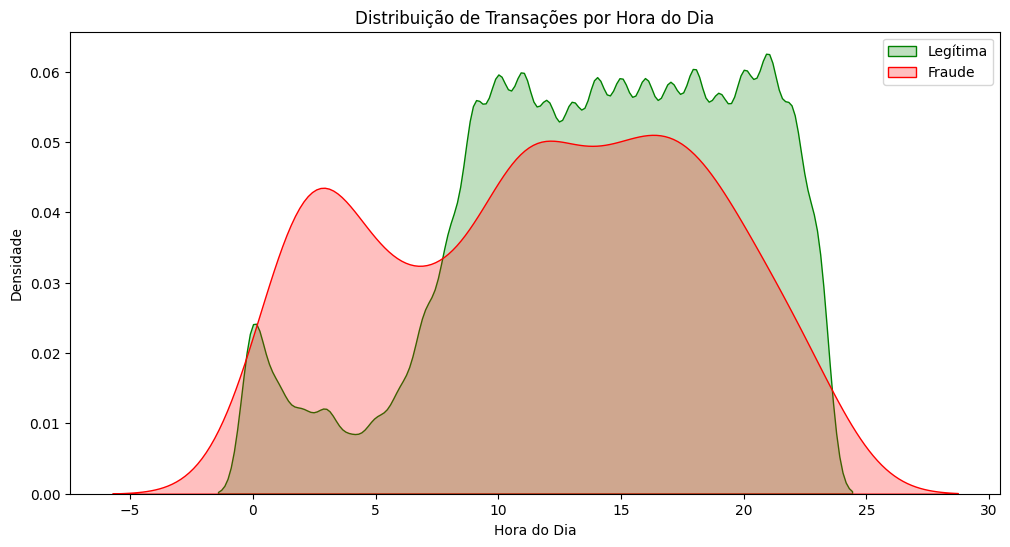

In [23]:
# Converter segundos para horas (0-23)
df['Hour'] = (df['Time'] // 3600) % 24

plt.figure(figsize=(12, 6))
sns.kdeplot(df[df['Class'] == 0]['Hour'], label='Legítima', fill=True, color='g')
sns.kdeplot(df[df['Class'] == 1]['Hour'], label='Fraude', fill=True, color='r')
plt.title('Distribuição de Transações por Hora do Dia')
plt.xlabel('Hora do Dia')
plt.ylabel('Densidade')
plt.legend()
plt.show()

### 3.2 Número total de transações por Hora do Dia

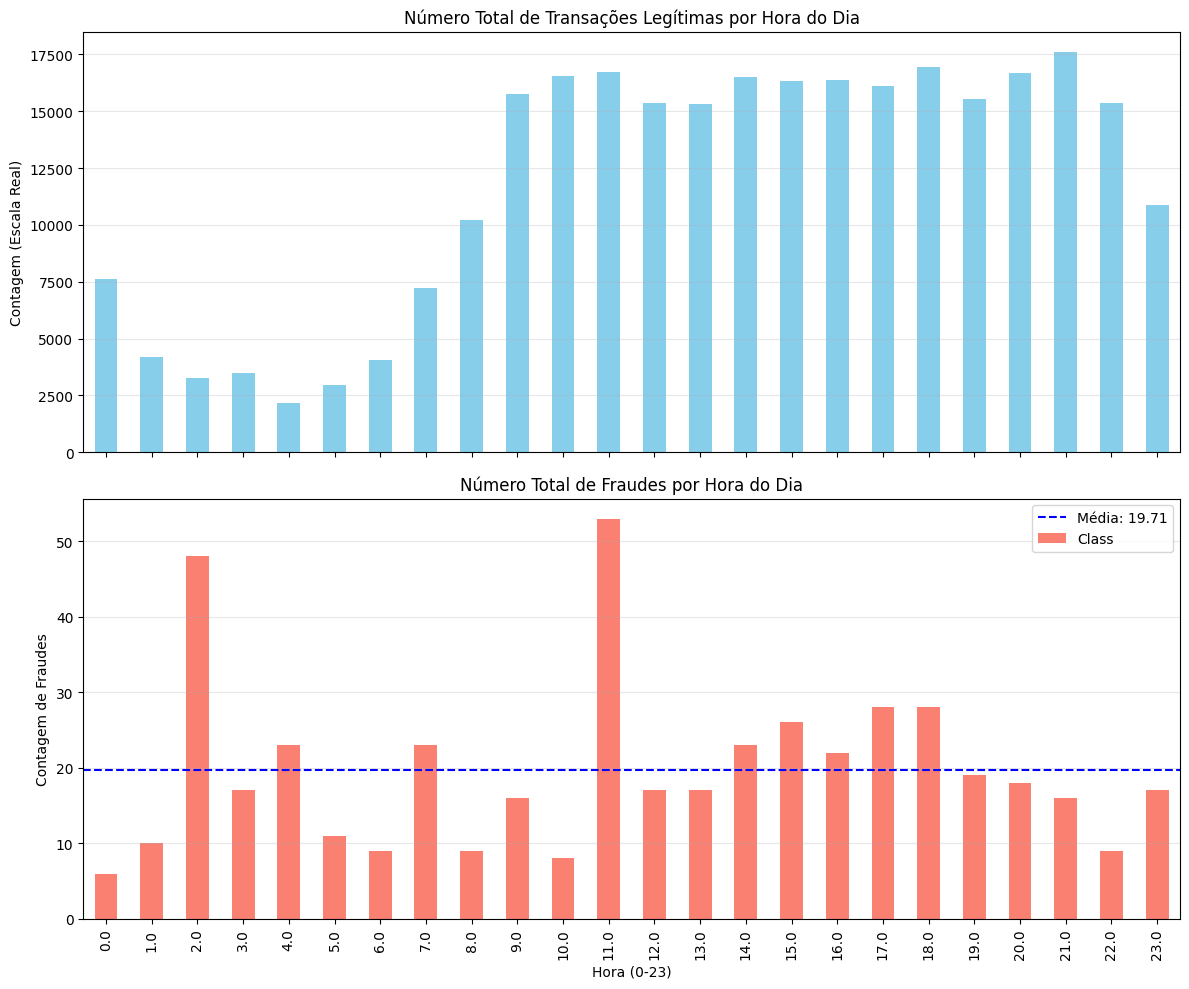

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Garantir que a coluna Hour existe
if 'Hour' not in df.columns:
    df['Hour'] = (df['Time'] // 3600) % 24

# Agrupando dados
legit_by_hour = df[df['Class'] == 0].groupby('Hour')['Class'].count()
fraud_by_hour = df[df['Class'] == 1].groupby('Hour')['Class'].count()

# Criando a visualização comparativa
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Gráfico 1: Transações Legítimas
legit_by_hour.plot(kind='bar', color='skyblue', ax=ax1)
ax1.set_title('Número Total de Transações Legítimas por Hora do Dia')
ax1.set_ylabel('Contagem (Escala Real)')
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Transações Fraudulentas
fraud_by_hour.plot(kind='bar', color='salmon', ax=ax2)
avg_fraud_per_hour = fraud_by_hour.mean()
ax2.axhline(y=avg_fraud_per_hour, color='blue', linestyle='--', label=f'Média: {avg_fraud_per_hour:.2f}')
ax2.set_title('Número Total de Fraudes por Hora do Dia')
ax2.set_xlabel('Hora (0-23)')
ax2.set_ylabel('Contagem de Fraudes')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Análise e Insights - Seção 2 e 3 (Time & Hour)

- **Comportamento Temporal**: A feature `Time` original tem correlação linear quase nula (-0.0124), indicando que o tempo bruto não prevê fraude.
- **Padrões por Hora**: Ao transformar em ciclos de 24h, notamos que a média de fraudes é de aproximadamente **19.71 por hora**.
- **Insights de Madrugada**: O gráfico de densidade mostra picos de fraude em horários de menor volume de transações legítimas (madrugada), confirmando que a hora do dia é uma feature mais informativa que o tempo linear.

## 6. Visualização do t-SNE de uma amostra do dataset

**O que será feito:**
Utilizaremos o t-SNE (*t-Distributed Stochastic Neighbor Embedding*), uma técnica de redução de dimensionalidade não-linear, para projetar as features do dataset em um plano bidimensional (2D).

**Por que será feito:**
Como o dataset possui muitas dimensões, o t-SNE permite visualizar se as transações fraudulentas formam agrupamentos distintos das legítimas, validando visualmente a separabilidade dos dados — complementando as análises de correlação e distribuição das seções anteriores.

In [ ]:
features_neg = ['V14', 'V17', 'V12']  # correlação negativa com fraude
features_pos = ['V4', 'V11']           # correlação positiva com fraude
features_to_plot = features_neg + features_pos

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    sns.kdeplot(df[df['Class'] == 0][feat], ax=axes[i],
                label='Legítima', color='g', fill=True, alpha=0.4)
    sns.kdeplot(df[df['Class'] == 1][feat], ax=axes[i],
                label='Fraude',   color='r', fill=True, alpha=0.4)
    axes[i].set_title(f'{feat}  (corr. {"negativa" if feat in features_neg else "positiva"} com fraude)')
    axes[i].set_xlabel(feat)
    axes[i].legend(fontsize=8)

# Oculta o eixo extra (6 features, 6 subplots — nenhum sobra)
plt.suptitle('Distribuição das Features mais Correlacionadas com Fraude vs. Legítima',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabela de sobreposição: quanto as medianas diferem entre as classes
print("Mediana por classe para as features selecionadas:")
print(df.groupby('Class')[features_to_plot].median().round(3))

## 5. Distribuição das Features mais Correlacionadas com Fraude

O heatmap de correlação (seção 1.2) identificou as features com maior associação linear com `Class`. Aqui visualizamos a **distribuição dessas features separada por classe**, o que revela a forma e a sobreposição das distribuições — informação que um único número de correlação não captura.

- **V14, V17, V12:** correlação negativa forte — valores mais baixos indicam fraude
- **V4, V11:** correlação positiva — valores mais altos indicam fraude

### Análise e Insights — Seção 4 (Amount por Classe)

- **Mediana das fraudes é menor:** transações fraudulentas têm valor mediano significativamente inferior ao das legítimas, consistente com a hipótese de *card testing*.
- **Ausência de fraudes em valores muito altos:** a cauda direita do KDE mostra que transações de alto valor (acima de ~€2.000) são quase exclusivamente legítimas — fraudadores raramente arriscam grandes valores sem testar o cartão antes.
- **Concentração entre €1 e €200:** a maioria das fraudes ocorre nessa faixa, enquanto transações legítimas se distribuem de forma mais uniforme ao longo das faixas de valor.
- **Conclusão:** `Amount` carrega sinal preditivo relevante, especialmente nas extremidades da distribuição. Normalizar com `RobustScaler` preserva essa estrutura ao usar mediana e IQR em vez de média e desvio padrão, sendo mais resistente a outliers de alto valor.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

legit_amount = df[df['Class'] == 0]['Amount']
fraud_amount = df[df['Class'] == 1]['Amount']

# KDE com escala logarítmica no eixo X para acomodar a cauda longa
axes[0].set_xscale('log')
sns.kdeplot(legit_amount + 0.01, ax=axes[0], label='Legítima', color='g', fill=True, alpha=0.5)
sns.kdeplot(fraud_amount + 0.01, ax=axes[0], label='Fraude',   color='r', fill=True, alpha=0.5)
axes[0].set_title('Distribuição do Amount por Classe (escala log)')
axes[0].set_xlabel('Amount (€) — escala logarítmica')
axes[0].legend()

# Boxplot para visualizar mediana e dispersão
df.boxplot(column='Amount', by='Class', ax=axes[1], notch=False,
           boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Amount por Classe (Boxplot)')
axes[1].set_xlabel('Classe (0 = Legítima, 1 = Fraude)')
axes[1].set_ylabel('Amount (€)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print("Estatísticas do Amount por classe (€):")
print(df.groupby('Class')['Amount'].describe().round(2))

## 4. Análise do Amount por Classe

Uma das análises mais reveladoras em detecção de fraude é a **distribuição do valor da transação por classe**. A hipótese clássica é que fraudadores frequentemente realizam transações menores primeiro — o chamado *card testing* — para verificar se o cartão funciona antes de realizar compras de alto valor.

Vamos comparar as distribuições de `Amount` entre transações legítimas e fraudulentas.

## 4. Visualização do t-SNE de uma amostra do dataset

**O que será feito:**
Utilizaremos o t-SNE (*t-Distributed Stochastic Neighbor Embedding*), uma técnica de redução de dimensionalidade não-linear, para projetar as 30 features do dataset em um plano bidimensional (2D).

**Por que será feito:**
Como o dataset possui muitas dimensões, o t-SNE permite visualizar se as transações fraudulentas formam agrupamentos distintos das legítimas, validando visualmente a separabilidade dos dados antes da modelagem.

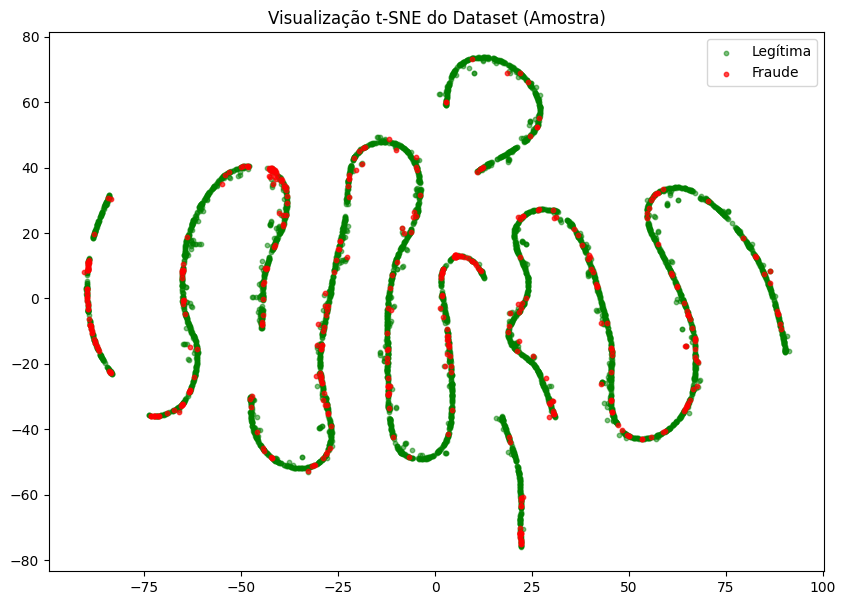

In [7]:
from sklearn.manifold import TSNE

# Amostrar os dados para não travar o kernel (ex: 5000 normais + todas as fraudes)
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0].sample(5000, random_state=42)
df_tsne = pd.concat([fraud, legit])

X_tsne = df_tsne.drop(['Class'], axis=1)
y_tsne = df_tsne['Class']

tsne = TSNE(n_components=2, random_state=42)
X_transformed = tsne.fit_transform(X_tsne)

plt.figure(figsize=(10, 7))
plt.scatter(X_transformed[y_tsne == 0, 0], X_transformed[y_tsne == 0, 1], label='Legítima', alpha=0.5, c='g', s=10)
plt.scatter(X_transformed[y_tsne == 1, 0], X_transformed[y_tsne == 1, 1], label='Fraude', alpha=0.7, c='r', s=10)
plt.title('Visualização t-SNE do Dataset (Amostra)')
plt.legend()
plt.show()

### Análise e Insights - Seção 4 (t-SNE)

- **Agrupamento**: O t-SNE revela que, mesmo em apenas duas dimensões, a maioria das transações fraudulentas (pontos vermelhos) tende a se agrupar ou se afastar da massa principal de transações legítimas.
- **Separabilidade**: Isso indica que o problema é viável para modelos de classificação, pois existe uma distinção estatística e espacial entre as classes, apesar do desbalanceamento extremo.

## 5. Normalização dos dados

Nesta etapa, preparamos o `Amount` para visualização comparável com as demais features.

**Por que normalizar o `Amount`?**
As variáveis `V1` a `V28` são resultado de PCA e já estão em escala reduzida. O `Amount` preserva a escala monetária original (0 a ~25.000), o que dificulta visualizações e prejudica modelos sensíveis a magnitude, como Regressão Logística e SVM.

> **Nota metodológica:** aqui na EDA o `RobustScaler` é ajustado sobre o dataset completo, **antes** de qualquer divisão treino/teste. Isso é aceitável num contexto puramente exploratório — o objetivo é visualizar os dados, não treinar um modelo. Para o **XGBoost especificamente**, o escalonamento não afeta os resultados (árvores de decisão são invariantes a transformações monotônicas da escala).
>
> O protocolo correto para modelagem — `fit` do scaler **apenas no treino**, `transform` no teste — está implementado no notebook de Modelagem, seção 1 (Benchmarking).

In [ ]:
from sklearn.preprocessing import RobustScaler

# Escalonamento para fins de visualização (pré-split — ver nota metodológica acima).
# O pipeline de modelagem aplica o scaler após o split treino/teste.
if 'Amount' in df.columns:
    rs = RobustScaler()
    df['scaled_amount'] = rs.fit_transform(df['Amount'].values.reshape(-1,1))

    cols_to_drop = [c for c in ['Time', 'Amount'] if c in df.columns]
    df.drop(cols_to_drop, axis=1, inplace=True)

    scaled_amount = df['scaled_amount']
    df.drop(['scaled_amount'], axis=1, inplace=True)
    df.insert(0, 'scaled_amount', scaled_amount)

print("Colunas atuais no DataFrame:", df.columns.tolist())
display(df.head())

## 6. Próximos Passos e Estratégia de Modelagem

Para as próximas etapas, seguiremos o seguinte roteiro para garantir a máxima performance na detecção de fraudes:

1.  **Divisão Estratificada**: Realizar o split entre treino e teste (80/20) garantindo que a proporção de fraudes seja mantida em ambos os sets.
2.  **Cost-Sensitive Learning**: Em vez de balancear o dataset (o que pode remover informações valiosas das transações legítimas), utilizaremos o parâmetro `scale_pos_weight` no **XGBoost**. Isso forçará o modelo a penalizar severamente erros cometidos na classe minoritária (Fraude).
3.  **Otimização com Optuna**: Utilizar busca de hiperparâmetros focada exclusivamente na métrica **PR-AUC** (Area Under the Precision-Recall Curve), que é mais robusta para datasets desbalanceados do que a acurácia ou a curva ROC.
4.  **Calibração de Probabilidades**: Implementar **Platt Scaling** ou **Isotonic Regression** para calibrar as saídas do modelo, garantindo que as probabilidades estimadas reflitam o risco real para a operação de negócio.